# 7150CEM - Data Science

# DETERMINANTS OF LOCAL CRIME TRENDS: A BOROUGH-LEVEL LONGITUDINAL AND SPATIAL ECONOMETRIC STUDY OF ENGLAND AND WALES (2020–2025)

## Lakshmi Purna Bindu Marothi

## 16322217

### PHASE 1: DATA PREPARATION

In [29]:
# =========================
# PHASE 1: DATA PREPARATION
# =========================

import pandas as pd
import numpy as np

# -------------------------
# FILE PATHS
# -------------------------
crime_file = "England_and_Wales_Crime_Data.xlsx"
population_file = "UK_Population.xlsx"
geo_file = "Geographic_Reference.xlsx"

# =========================
# 1. LOAD & INSPECT CRIME DATA
# =========================

print("\n--- CRIME DATA LOADING ---")
xls = pd.ExcelFile(crime_file)
print("Sheets:", xls.sheet_names)

crime_list = []

for sheet in xls.sheet_names:
    df = pd.read_excel(crime_file, sheet_name=sheet)
    
    print(f"\n--- {sheet} ---")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nDtypes:\n", df.dtypes)
    print("\nMissing Values:\n", df.isna().sum())
    
    df["Year"] = sheet[:4]  # Extract year (2020 etc.)
    crime_list.append(df)

crime_df = pd.concat(crime_list, ignore_index=True)

print("\n--- COMBINED CRIME DATA ---")
print("Shape:", crime_df.shape)
print(crime_df.head())

# =========================
# 2. CLEAN & AGGREGATE CRIME DATA
# =========================

# Keep relevant columns
crime_df = crime_df[[
    "CSP Name",
    "Year",
    "Offence Count"
]]

# Convert types
crime_df["Year"] = crime_df["Year"].astype(int)
crime_df["Offence Count"] = pd.to_numeric(crime_df["Offence Count"], errors='coerce')

# Check missing after conversion
print("\nMissing after cleaning:\n", crime_df.isna().sum())

# Aggregate (CSP × Year)
crime_agg = crime_df.groupby(["CSP Name", "Year"])["Offence Count"].sum().reset_index()
crime_agg.rename(columns={"Offence Count": "Total_Crime"}, inplace=True)

print("\n--- AGGREGATED CRIME DATA ---")
print(crime_agg.head())
print("Shape:", crime_agg.shape)

# =========================
# 3. LOAD & INSPECT POPULATION DATA
# =========================

print("\n--- POPULATION DATA ---")
pop_df = pd.read_excel(population_file)

print("Shape:", pop_df.shape)
print("Columns:", pop_df.columns.tolist())
print("\nDtypes:\n", pop_df.dtypes)
print("\nMissing Values:\n", pop_df.isna().sum())
print(pop_df.head())

# =========================
# 4. TRANSFORM POPULATION (WIDE → LONG)
# =========================

pop_long = pop_df.melt(
    id_vars=["laname23"],
    value_vars=[
        "population_2020",
        "population_2021",
        "population_2022",
        "population_2023",
        "population_2024"
    ],
    var_name="Year",
    value_name="Population"
)

# Extract year
pop_long["Year"] = pop_long["Year"].str[-4:].astype(int)

# Rename column
pop_long.rename(columns={"laname23": "CSP Name"}, inplace=True)

print("\n--- POPULATION LONG FORMAT ---")
print(pop_long.head())
print("Shape:", pop_long.shape)

# =========================
# 5. EXTRAPOLATE 2025 POPULATION
# =========================

pop_2025 = []

for csp in pop_long["CSP Name"].unique():
    temp = pop_long[pop_long["CSP Name"] == csp].sort_values("Year")
    
    if len(temp) >= 2:
        growth = temp["Population"].pct_change().mean()
        last_pop = temp[temp["Year"] == 2024]["Population"].values
        
        if len(last_pop) > 0:
            est_2025 = last_pop[0] * (1 + growth)
            pop_2025.append([csp, 2025, est_2025])

pop_2025_df = pd.DataFrame(pop_2025, columns=["CSP Name", "Year", "Population"])

# Append
pop_final = pd.concat([pop_long, pop_2025_df], ignore_index=True)

print("\n--- POPULATION WITH 2025 ---")
print(pop_final.tail())

# =========================
# 6. LOAD & INSPECT GEOGRAPHIC DATA
# =========================

print("\n--- GEOGRAPHIC DATA ---")
geo_df = pd.read_excel(geo_file)

print("Shape:", geo_df.shape)
print("Columns:", geo_df.columns.tolist())
print("\nMissing Values:\n", geo_df.isna().sum())
print(geo_df.head())

# =========================
# 7. MERGE DATASETS
# =========================

# Merge crime + population
master = crime_agg.merge(pop_final, on=["CSP Name", "Year"], how="left")

print("\n--- AFTER MERGING POPULATION ---")
print("Missing values:\n", master.isna().sum())

# Merge geographic reference (optional but recommended)
master = master.merge(geo_df, on="CSP Name", how="left")

print("\n--- AFTER MERGING GEOGRAPHY ---")
print("Missing values:\n", master.isna().sum())

# =========================
# 8. CREATE CRIME RATE
# =========================

master["Crime_Rate"] = (master["Total_Crime"] / master["Population"]) * 1000

print("\n--- FINAL MASTER DATASET ---")
print(master.head())
print("Shape:", master.shape)

# =========================
# 9. FINAL CHECKS
# =========================

print("\n--- FINAL SUMMARY ---")
print(master.describe())

print("\nUnique CSP count:", master["CSP Name"].nunique())
print("Year range:", master["Year"].min(), "-", master["Year"].max())

print("\nFinal Missing Values:\n", master.isna().sum())

# Save final dataset
master.to_csv("MASTER_DATASET.csv", index=False)

print("\n Phase 1 Complete. Master dataset saved.")


--- CRIME DATA LOADING ---
Sheets: ['2020_21', '2021_22', '2022_23', '2023_24', '2024_25', '2025_26']

--- 2020_21 ---
Shape: (181356, 9)
Columns: ['Financial Year', 'Financial Quarter', 'Police Force', 'CSP Name', 'Offence Description', 'Offence Group', 'Offence Subgroup', 'Offence Code', 'Offence Count']

Dtypes:
 Financial Year         object
Financial Quarter       int64
Police Force           object
CSP Name               object
Offence Description    object
Offence Group          object
Offence Subgroup       object
Offence Code           object
Offence Count           int64
dtype: object

Missing Values:
 Financial Year         0
Financial Quarter      0
Police Force           0
CSP Name               0
Offence Description    0
Offence Group          0
Offence Subgroup       0
Offence Code           0
Offence Count          0
dtype: int64

--- 2021_22 ---
Shape: (181356, 9)
Columns: ['Financial Year', 'Financial Quarter', 'Police Force', 'CSP Name', 'Offence Description', 'Offe

In [30]:
import pandas as pd
import numpy as np

# =========================
# LOAD MASTER DATASET
# =========================
file_path = "MASTER_DATASET.xlsx"

# Safest way (auto-detect sheet)
df = pd.read_excel(file_path)

print("Initial shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing before fix:\n", df.isna().sum())

# =========================
# IDENTIFY PROBLEM ROWS
# =========================
problem_mask = df["Force Name"].isna() | df["Region"].isna()

print("\nNumber of problematic rows:", problem_mask.sum())
print("\nProblem CSP names:")
print(sorted(df.loc[problem_mask, "CSP Name"].dropna().unique()))

# =========================
# STEP 1: FIX FORCE NAME
# =========================
df.loc[df["Force Name"].isna(), "Force Name"] = df.loc[
    df["Force Name"].isna(), "CSP Name"
]

# =========================
# STEP 2: FIX REGION
# =========================
force_to_region = {
    "Avon & Somerset": "South West Region",
    "Bedfordshire": "Eastern Region",
    "Cambridgeshire": "Eastern Region",
    "Cheshire": "North West Region",
    "Cleveland": "North East Region",
    "Cumbria": "North West Region",
    "Derbyshire": "East Midlands Region",
    "Devon & Cornwall": "South West Region",
    "Dorset": "South West Region",
    "Durham": "North East Region",
    "Dyfed-Powys": "Wales",
    "Essex": "Eastern Region",
    "Gloucestershire": "South West Region",
    "Greater Manchester": "North West Region",
    "Gwent": "Wales",
    "Hampshire": "South East Region",
    "Hertfordshire": "Eastern Region",
    "Humberside": "Yorkshire and the Humber",
    "Kent": "South East Region",
    "Lancashire": "North West Region",
    "Leicestershire": "East Midlands Region",
    "Lincolnshire": "East Midlands Region",
    "Merseyside": "North West Region",
    "Metropolitan Police": "London Region",
    "Norfolk": "Eastern Region",
    "North Wales": "Wales",
    "North Yorkshire": "Yorkshire and the Humber",
    "Northamptonshire": "East Midlands Region",
    "Northumbria": "North East Region",
    "Nottinghamshire": "East Midlands Region",
    "South Wales": "Wales",
    "South Yorkshire": "Yorkshire and the Humber",
    "Staffordshire": "West Midlands Region",
    "Suffolk": "Eastern Region",
    "Surrey": "South East Region",
    "Sussex": "South East Region",
    "Thames Valley": "South East Region",
    "Warwickshire": "West Midlands Region",
    "West Mercia": "West Midlands Region",
    "West Midlands": "West Midlands Region",
    "West Yorkshire": "Yorkshire and the Humber",
    "Wiltshire": "South West Region"
}

df.loc[df["Region"].isna(), "Region"] = df.loc[
    df["Region"].isna(), "Force Name"
].map(force_to_region)

# =========================
# STEP 3: REGION-YEAR AVERAGE POPULATION
# =========================
good_rows = ~(problem_mask)

region_year_avg_pop = (
    df.loc[good_rows]
      .groupby(["Region", "Year"])["Population"]
      .mean()
      .reset_index()
      .rename(columns={"Population": "Region_Year_Avg_Pop"})
)

# Merge back
df = df.merge(region_year_avg_pop, on=["Region", "Year"], how="left")

# =========================
# STEP 4: IMPUTE POPULATION
# =========================
df.loc[problem_mask, "Population"] = df.loc[
    problem_mask, "Region_Year_Avg_Pop"
]

# =========================
# STEP 5: RECALCULATE CRIME RATE
# =========================
df["Crime_Rate"] = (df["Total_Crime"] / df["Population"]) * 1000

# =========================
# STEP 6: CLEANUP
# =========================
df.drop(columns=["Region_Year_Avg_Pop"], inplace=True)

# =========================
# STEP 7: FINAL CHECKS
# =========================
print("\nMissing after fix:\n", df.isna().sum())

print("\nSample fixed rows:")
print(df.loc[problem_mask].head(20)[
    ["CSP Name", "Year", "Force Name", "Region", "Population", "Crime_Rate"]
])

# =========================
# STEP 8: SAVE FINAL DATASET
# =========================

# Save as CSV
df.to_csv("MASTER_DATASET_FINAL.csv", index=False)

# Save as Excel (recommended for submission)
df.to_excel("MASTER_DATASET_FINAL.xlsx", index=False)

print("\n Fixed dataset saved successfully!")

Initial shape: (2124, 13)

Columns: ['CSP Name', 'Year', 'Total_Crime', 'Population', 'Force Name', 'Region', 'ONS Code', 'Crime_Rate', 'IMD_Rank', 'IMD', 'Police_FTE', 'Police_per_1000', 'Force_Pop']

Missing before fix:
 CSP Name             0
Year                 0
Total_Crime          0
Population         462
Force Name         282
Region             282
ONS Code           288
Crime_Rate         462
IMD_Rank             0
IMD                  0
Police_FTE           0
Police_per_1000    282
Force_Pop          282
dtype: int64

Number of problematic rows: 282

Problem CSP names:
['Cwm Taf', 'Folkestone and Hythe', 'Kings Lynn and West Norfolk', 'London, City of', 'Manchester Airport', 'Unassigned Avon & Somerset', 'Unassigned Bedfordshire', 'Unassigned Cambridgeshire', 'Unassigned Cheshire', 'Unassigned Cleveland', 'Unassigned Cumbria', 'Unassigned Derbyshire', 'Unassigned Devon & Cornwall', 'Unassigned Dorset', 'Unassigned Durham', 'Unassigned Dyfed-Powys', 'Unassigned Essex', 'Unas

In [34]:
# =========================
# LOAD DATA
# =========================
import pandas as pd

file_path = "MASTER_DATASET.csv"
df = pd.read_csv(file_path)

print("Initial shape:", df.shape)

# =========================
# STEP 1: IDENTIFY FORCE-LEVEL ROWS
# (CSP Name == Force Name)
# =========================
force_rows_mask = df["CSP Name"] == df["Force Name"]

print("\nNumber of force-level rows:", force_rows_mask.sum())

# =========================
# STEP 2: PROCESS EACH FORCE-YEAR
# =========================

# Get unique force-year combinations from these rows
force_years = df.loc[force_rows_mask, ["Force Name", "Year", "Total_Crime"]]

for idx, row in force_years.iterrows():
    
    force = row["Force Name"]
    year = row["Year"]
    total_force_crime = row["Total_Crime"]
    
    # Get CSPs under this force (excluding the force row itself)
    csp_mask = (
        (df["Force Name"] == force) &
        (df["Year"] == year) &
        (df["CSP Name"] != force)
    )
    
    csp_count = df.loc[csp_mask].shape[0]
    
    if csp_count > 0:
        share = total_force_crime / csp_count
        
        # Add equal share to each CSP
        df.loc[csp_mask, "Total_Crime"] += share

# =========================
# STEP 3: REMOVE FORCE-LEVEL ROWS
# =========================
df = df[~force_rows_mask].reset_index(drop=True)

print("\nShape after removing force rows:", df.shape)

# =========================
# STEP 4: RECALCULATE CRIME RATE
# =========================
df["Crime_Rate"] = (df["Total_Crime"] / df["Population"]) * 1000

# =========================
# STEP 5: VALIDATION
# =========================

print("\nCheck duplicates (CSP-Year):")
duplicates = df.duplicated(subset=["CSP Name", "Year"]).sum()
print("Duplicate rows:", duplicates)

print("\nMissing values after fix:\n", df.isna().sum())

print("\nSample cleaned data:")
print(df.head())

# =========================
# STEP 6: SAVE FINAL DATASET
# =========================
output_path = "MASTER_DATASET.xlsx"
df.to_excel(output_path, index=False)

print(f"\n Final cleaned dataset saved to:\n{output_path}")

Initial shape: (2142, 8)

Number of force-level rows: 18

Shape after removing force rows: (2124, 8)

Check duplicates (CSP-Year):
Duplicate rows: 0

Missing values after fix:
 CSP Name         0
Year             0
Total_Crime      0
Population     462
Force Name     282
Region         282
ONS Code       288
Crime_Rate     462
dtype: int64

Sample cleaned data:
  CSP Name  Year  Total_Crime  Population Force Name             Region  \
0     Adur  2020       3777.0     64550.0     Sussex  South East Region   
1     Adur  2021       4162.0     64632.0     Sussex  South East Region   
2     Adur  2022       4433.0     64760.0     Sussex  South East Region   
3     Adur  2023       4831.0     64688.0     Sussex  South East Region   
4     Adur  2024       4184.0     64889.0     Sussex  South East Region   

    ONS Code  Crime_Rate  
0  E22000290   58.512781  
1  E22000290   64.395346  
2  E22000290   68.452749  
3  E22000290   74.681548  
4  E22000290   64.479342  


C:\Users\Bindu\AppData\Local\Temp\ipykernel_7556\2881124197.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[27669.5 19418.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[csp_mask, "Total_Crime"] += share



 Final cleaned dataset saved to:
MASTER_DATASET.xlsx


### PHASE 2: ADD EXPLANATORY VARIABLES

In [35]:
import pandas as pd
import numpy as np

# =========================
# FILE PATHS
# =========================
master_file = "MASTER_DATASET.xlsx"
imd_file = "IMD_Data.xlsx"

# =========================
# LOAD DATA
# =========================
master = pd.read_excel(master_file)
imd = pd.read_excel(imd_file)

print("MASTER shape:", master.shape)
print("IMD shape:", imd.shape)

# =========================
# STANDARDISE COLUMN NAMES
# =========================
imd = imd.rename(columns={
    "Local Authority District name (2025)": "LAD_Name",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "IMD_Rank"
})

# =========================
# CLEAN TEXT FUNCTION
# =========================
def clean_name(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace(",", "")
        .replace("'", "")
        .replace(".", "")
        .replace("&", "and")
    )

master["CSP_clean"] = master["CSP Name"].apply(clean_name)
imd["LAD_clean"] = imd["LAD_Name"].apply(clean_name)

# =========================
# EXACT MATCH LIST
# These are the names you confirmed already match
# =========================
exact_matches = [
    "Adur","Amber Valley","Arun","Ashfield","Ashford","Barking and Dagenham","Barnet","Barnsley",
    "Basildon","Bassetlaw","Bath and North East Somerset","Bedford","Bexley","Birmingham","Blaby",
    "Blackburn with Darwen","Blackpool","Bolsover","Bolton","Boston","Bracknell Forest","Bradford",
    "Braintree","Breckland","Brent","Brentwood","Brighton and Hove","Bristol, City of","Broadland",
    "Bromley","Broxbourne","Burnley","Bury","Calderdale","Cambridge","Camden","Cannock Chase",
    "Canterbury","Castle Point","Central Bedfordshire","Charnwood","Chelmsford","Cheltenham",
    "Cherwell","Cheshire East","Cheshire West and Chester","Chesterfield","Chichester","Chorley",
    "Colchester","Cornwall","Cotswold","County Durham","Coventry","Crawley","Croydon","Dacorum",
    "Darlington","Derby","Derbyshire Dales","Doncaster","Dover","Dudley","Ealing","East Cambridgeshire",
    "East Hampshire","East Hertfordshire","East Lindsey","East Riding of Yorkshire","East Staffordshire",
    "Eastbourne","Eastleigh","Elmbridge","Enfield","Epping Forest","Epsom and Ewell","Erewash","Exeter",
    "Fareham","Fenland","Folkestone and Hythe","Forest of Dean","Fylde","Gateshead","Gloucester",
    "Gosport","Great Yarmouth","Greenwich","Guildford","Hackney","Halton","Hammersmith and Fulham",
    "Harborough","Haringey","Harlow","Harrow","Hartlepool","Hastings","Havant","Havering",
    "Herefordshire, County of","Hertsmere","High Peak","Hillingdon","Hinckley and Bosworth","Horsham",
    "Hounslow","Huntingdonshire","Hyndburn","Ipswich","Isle of Wight","Isles of Scilly","Islington",
    "Kensington and Chelsea","Kingston upon Hull, City of","Kingston upon Thames","Kirklees","Knowsley",
    "Lambeth","Lancaster","Leeds","Leicester","Lewes","Lewisham","Lichfield","Lincoln","Liverpool",
    "Luton","Maidstone","Maldon","Manchester","Mansfield","Medway","Melton","Merton","Mid Sussex",
    "Middlesbrough","Milton Keynes","Mole Valley","New Forest","Newark and Sherwood","Newcastle upon Tyne",
    "Newcastle-under-Lyme","Newham","North East Derbyshire","North East Lincolnshire","North Hertfordshire",
    "North Kesteven","North Lincolnshire","North Norfolk","North Somerset","North Tyneside",
    "North Warwickshire","North West Leicestershire","Northumberland","Norwich","Nottingham",
    "Nuneaton and Bedworth","Oadby and Wigston","Oldham","Oxford","Pendle","Peterborough","Plymouth",
    "Portsmouth","Preston","Reading","Redbridge","Redcar and Cleveland","Reigate and Banstead",
    "Ribble Valley","Richmond upon Thames","Rochdale","Rochford","Rossendale","Rother","Rotherham",
    "Rugby","Runnymede","Rutland","Salford","Sandwell","Sefton","Sevenoaks","Sheffield","Shropshire",
    "Slough","Solihull","Somerset","South Cambridgeshire","South Derbyshire","South Gloucestershire",
    "South Holland","South Kesteven","South Norfolk","South Oxfordshire","South Ribble",
    "South Staffordshire","South Tyneside","Southampton","Southend-on-Sea","Southwark","Spelthorne",
    "St Albans","St. Helens","Stafford","Staffordshire Moorlands","Stevenage","Stockport",
    "Stockton-on-Tees","Stoke-on-Trent","Stroud","Sunderland","Surrey Heath","Sutton","Swale","Swindon",
    "Tameside","Tamworth","Tandridge","Telford and Wrekin","Tendring","Test Valley","Tewkesbury",
    "Thanet","Three Rivers","Thurrock","Tonbridge and Malling","Torbay","Tower Hamlets","Trafford",
    "Tunbridge Wells","Uttlesford","Vale of White Horse","Wakefield","Walsall","Waltham Forest",
    "Wandsworth","Warrington","Watford","Waverley","Wealden","Welwyn Hatfield","West Berkshire",
    "West Lancashire","West Lindsey","West Oxfordshire","Westminster","Wigan","Winchester",
    "Windsor and Maidenhead","Wirral","Woking","Wokingham","Wolverhampton","Worthing","Wyre"
]

exact_matches_clean = set(clean_name(x) for x in exact_matches)

# =========================
# KEEP ONLY MATCHABLE IMD ROWS
# =========================
imd_exact = imd[imd["LAD_clean"].isin(exact_matches_clean)].copy()

# =========================
# FIRST MERGE: EXACT MATCHES
# =========================
master = master.merge(
    imd_exact[["LAD_clean", "IMD_Rank"]],
    left_on="CSP_clean",
    right_on="LAD_clean",
    how="left"
)

print("\nMissing IMD after exact merge:", master["IMD_Rank"].isna().sum())

# =========================
# MANUAL CROSSWALK FOR LEGACY / CSP NAMES
# These are CSP names in master that do not directly exist in IMD
# We map them to modern LAD names or composite areas
# =========================
manual_map = {
    "aylesbury vale": "buckinghamshire",
    "bournemouth": "bournemouth christchurch and poole",
    "chiltern": "buckinghamshire",
    "corby": "north northamptonshire",
    "dartford and gravesham": ["dartford", "gravesham"],
    "daventry and south northamptonshire": "west northamptonshire",
    "east northamptonshire": "north northamptonshire",
    "east and mid devon": ["east devon", "mid devon"],
    "kettering": "north northamptonshire",
    "kings lynn and west norfolk": "kings lynn and west norfolk",   # cleaned exact spelling
    "manchester airport": "manchester",
    "north hampshire": ["basingstoke and deane", "hart", "rushmoor"],
    "north worcestershire": ["bromsgrove", "redditch", "wyre forest"],
    "northampton": "west northamptonshire",
    "northern devon": ["north devon", "torridge"],
    "poole": "bournemouth christchurch and poole",
    "south bucks": "buckinghamshire",
    "south devon and dartmoor": ["south hams", "teignbridge", "west devon"],
    "south lakeland": "westmorland and furness",
    "south nottinghamshire": ["broxtowe", "gedling", "rushcliffe"],
    "south warwickshire": ["stratford-on-avon", "warwick"],
    "south worcester": ["worcester", "malvern hills", "wychavon"],
    "suffolk coastal": "east suffolk",
    "waveney": "east suffolk",
    "wellingborough": "north northamptonshire",
    "western suffolk": "west suffolk",
    "wycombe": "buckinghamshire"
}

imd_lookup = dict(zip(imd["LAD_clean"], imd["IMD_Rank"]))

def get_manual_imd(csp_clean):
    if csp_clean not in manual_map:
        return np.nan
    target = manual_map[csp_clean]
    if isinstance(target, list):
        vals = [imd_lookup.get(clean_name(t), np.nan) for t in target]
        vals = [v for v in vals if pd.notna(v)]
        return np.mean(vals) if len(vals) > 0 else np.nan
    return imd_lookup.get(clean_name(target), np.nan)

# fill manual matches only where still missing
mask_missing = master["IMD_Rank"].isna()
master.loc[mask_missing, "IMD_Rank"] = master.loc[mask_missing, "CSP_clean"].apply(get_manual_imd)

print("Missing IMD after manual crosswalk:", master["IMD_Rank"].isna().sum())

# =========================
# FILL REMAINING WITH REGION AVERAGE
# =========================
region_avg_imd = master.groupby("Region")["IMD_Rank"].transform("mean")
master["IMD_Rank"] = master["IMD_Rank"].fillna(region_avg_imd)

print("Missing IMD after region-average fill:", master["IMD_Rank"].isna().sum())

# =========================
# FINAL BACKUP: OVERALL MEAN
# This catches rows in regions with no direct IMD coverage
# =========================
overall_imd_mean = master["IMD_Rank"].mean()
master["IMD_Rank"] = master["IMD_Rank"].fillna(overall_imd_mean)

print("Final missing IMD:", master["IMD_Rank"].isna().sum())

# =========================
# CREATE INTERPRETABLE DEPRIVATION VARIABLE
# IMD rank: 1 = most deprived
# Reverse so higher = more deprived
# =========================
master["IMD"] = master["IMD_Rank"].max() - master["IMD_Rank"] + 1

# =========================
# DIAGNOSTICS
# =========================
print("\nIMD summary:")
print(master["IMD"].describe())

unmatched_after_all = master[master["IMD_Rank"].isna()][["CSP Name", "Region"]].drop_duplicates()
print("\nUnmatched rows after all steps:", unmatched_after_all.shape[0])

print("\nSample rows with IMD:")
print(master[["CSP Name", "Region", "Year", "IMD_Rank", "IMD"]].head(20))

# =========================
# CLEANUP
# =========================
master.drop(columns=["CSP_clean", "LAD_clean"], inplace=True, errors="ignore")

# =========================
# SAVE FINAL FILE
# =========================
output_file = "MASTER_DATASET.xlsx"
master.to_excel(output_file, index=False)

print(f"\n Final master dataset with IMD saved to:\n{output_file}")

MASTER shape: (2124, 8)
IMD shape: (296, 12)

Missing IMD after exact merge: 582
Missing IMD after manual crosswalk: 420
Missing IMD after region-average fill: 384
Final missing IMD: 0

IMD summary:
count    2124.000000
mean      150.928164
std        77.107480
min         1.000000
25%        93.000000
50%       150.928164
75%       209.000000
max       295.000000
Name: IMD, dtype: float64

Unmatched rows after all steps: 0

Sample rows with IMD:
        CSP Name                Region  Year    IMD_Rank         IMD
0           Adur     South East Region  2020  192.000000  104.000000
1           Adur     South East Region  2021  192.000000  104.000000
2           Adur     South East Region  2022  192.000000  104.000000
3           Adur     South East Region  2023  192.000000  104.000000
4           Adur     South East Region  2024  192.000000  104.000000
5           Adur     South East Region  2025  192.000000  104.000000
6      Allerdale     North West Region  2020  100.558824  195.4411

In [36]:
print(master.columns.tolist())

['CSP Name', 'Year', 'Total_Crime', 'Population', 'Force Name', 'Region', 'ONS Code', 'Crime_Rate', 'IMD_Rank', 'IMD']


In [37]:
print("Master columns:", master.columns.tolist())

Master columns: ['CSP Name', 'Year', 'Total_Crime', 'Population', 'Force Name', 'Region', 'ONS Code', 'Crime_Rate', 'IMD_Rank', 'IMD']


In [38]:
import pandas as pd
import numpy as np

# =========================
# LOAD POLICE DATA
# =========================
police = pd.read_excel("Police_Workforce.xlsx", sheet_name="Data")
print("Original police data shape:", police.shape)
print("Columns:", police.columns.tolist())

# =========================
# CLEAN YEAR
# =========================
police["Year"] = police["As at 31 March 2025"].astype(str).str[-4:].astype(int)

# =========================
# FILTER ONLY POLICE OFFICERS
# =========================
police = police[police["Worker type"] == "Police Officer"]

# =========================
# KEEP RELEVANT COLUMNS
# =========================
police = police[["Force name", "Year", "Total (FTE)"]]
police.rename(columns={
    "Force name": "Force Name",
    "Total (FTE)": "Police_FTE"
}, inplace=True)

# =========================
# AGGREGATE POLICE FTE BY FORCE AND YEAR
# =========================
police_agg = police.groupby(["Force Name", "Year"])["Police_FTE"].sum().reset_index()
print("\nAggregated police data (first 5 rows):")
print(police_agg.head())

# =========================
# CLEAN UP MASTER BEFORE MERGE
# =========================
# Drop old Police_FTE or Force_Pop columns to avoid _x/_y issues
for col in ["Police_FTE", "Police_FTE_x", "Police_FTE_y",
            "Force_Pop", "Force_Pop_x", "Force_Pop_y"]:
    if col in master.columns:
        master.drop(columns=[col], inplace=True)

# Strip whitespace from Force Name for safe merge
master["Force Name"] = master["Force Name"].str.strip()
police_agg["Force Name"] = police_agg["Force Name"].str.strip()

# =========================
# MERGE POLICE FTE INTO MASTER
# =========================
master = master.merge(police_agg, on=["Force Name", "Year"], how="left")

print("\nMissing police FTE values after merge:", master["Police_FTE"].isna().sum())

# =========================
# CALCULATE FORCE-LEVEL POPULATION
# =========================
force_pop = master.groupby(["Force Name", "Year"])["Population"].sum().reset_index()
force_pop.rename(columns={"Population": "Force_Pop"}, inplace=True)

force_pop["Force Name"] = force_pop["Force Name"].str.strip()
master["Force Name"] = master["Force Name"].str.strip()

master = master.merge(force_pop, on=["Force Name", "Year"], how="left")

print("\nColumns after merging Force_Pop:", master.columns.tolist())

# =========================
# HANDLE ZERO OR MISSING POPULATION (warning-free)
# =========================
master["Force_Pop"] = master["Force_Pop"].replace(0, np.nan)

# =========================
# CALCULATE POLICE PER 1000
# =========================
master["Police_per_1000"] = (master["Police_FTE"] / master["Force_Pop"]) * 1000

# Optional: fill NaN with 0 if desired
# master["Police_per_1000"] = master["Police_per_1000"].fillna(0)

# =========================
# FINAL CHECKS
# =========================
print("\nPolice per 1000 summary:")
print(master["Police_per_1000"].describe())

print("\nMissing values in key columns:")
print(master[["Police_FTE", "Force_Pop", "Police_per_1000"]].isna().sum())

# =========================
# SAVE FINAL DATASET
# =========================
master.to_excel("MASTER_DATASET.xlsx", index=False)
print("\nPolice variable successfully added and dataset saved.")

Original police data shape: (16192, 9)
Columns: ['As at 31 March 2025', 'Geocode', 'Force name', 'Region', 'Sex', 'Rank', 'Worker type', 'Total (Headcount)', 'Total (FTE)']

Aggregated police data (first 5 rows):
          Force Name  Year Police_FTE
0  Avon and Somerset  2020    2803.29
1  Avon and Somerset  2021    2996.85
2  Avon and Somerset  2022    3057.46
3  Avon and Somerset  2023     3330.3
4  Avon and Somerset  2024  3293.6663

Missing police FTE values after merge: 354

Columns after merging Force_Pop: ['CSP Name', 'Year', 'Total_Crime', 'Population', 'Force Name', 'Region', 'ONS Code', 'Crime_Rate', 'IMD_Rank', 'IMD', 'Police_FTE', 'Force_Pop']

Police per 1000 summary:
count     1680.000000
unique     222.000000
top          3.835733
freq        32.000000
Name: Police_per_1000, dtype: float64

Missing values in key columns:
Police_FTE         354
Force_Pop          372
Police_per_1000    444
dtype: int64

Police variable successfully added and dataset saved.


In [39]:
# =========================
# FIX FUTURE WARNING 
# =========================
pd.set_option('future.no_silent_downcasting', True)

# =========================
# STEP 1: FIX POLICE_FTE TYPE
# =========================
master["Police_FTE"] = pd.to_numeric(master["Police_FTE"], errors="coerce")

# =========================
# STEP 2: FILL MISSING POLICE_FTE
# =========================

region_year_police = master.groupby(["Region", "Year"])["Police_FTE"].transform("mean")
master["Police_FTE"] = master["Police_FTE"].fillna(region_year_police)

year_avg_police = master.groupby("Year")["Police_FTE"].transform("mean")
master["Police_FTE"] = master["Police_FTE"].fillna(year_avg_police)

overall_mean_police = master["Police_FTE"].mean()
master["Police_FTE"] = master["Police_FTE"].fillna(overall_mean_police)

print("Remaining missing Police_FTE:", master["Police_FTE"].isna().sum())

# =========================
# STEP 3: CREATE FORCE POPULATION 
# =========================

force_pop = (
    master.groupby(["Force Name", "Year"], as_index=False)["Population"]
    .sum()
)

# Rename BEFORE merge (IMPORTANT)
force_pop.rename(columns={"Population": "Force_Pop"}, inplace=True)

# =========================
# STEP 4: MERGE CLEANLY
# =========================

# Drop old Force_Pop if exists
if "Force_Pop" in master.columns:
    master = master.drop(columns=["Force_Pop"])

master = master.merge(force_pop, on=["Force Name", "Year"], how="left")

print("\nColumns after merge:")
print(master.columns)

# =========================
# STEP 5: CHECK FORCE_POP EXISTS
# =========================

if "Force_Pop" not in master.columns:
    raise Exception("Force_Pop column still missing — check merge keys")

# =========================
# STEP 6: CALCULATE POLICE INTENSITY
# =========================

master["Police_per_1000"] = (master["Police_FTE"] / master["Force_Pop"]) * 1000

# =========================
# FINAL CHECK
# =========================

print("\nFinal checks:")
print("Missing Police_FTE:", master["Police_FTE"].isna().sum())
print("Missing Force_Pop:", master["Force_Pop"].isna().sum())
print("Missing Police_per_1000:", master["Police_per_1000"].isna().sum())

print("\nSample:")
print(master[["CSP Name", "Force Name", "Year", "Police_FTE", "Force_Pop", "Police_per_1000"]].head())

# =========================
# SAVE FINAL DATASET
# =========================

master.to_excel("MASTER_DATASET.xlsx", index=False)

print("\n Dataset with Full Police Force")

Remaining missing Police_FTE: 0

Columns after merge:
Index(['CSP Name', 'Year', 'Total_Crime', 'Population', 'Force Name', 'Region',
       'ONS Code', 'Crime_Rate', 'IMD_Rank', 'IMD', 'Police_FTE',
       'Police_per_1000', 'Force_Pop'],
      dtype='object')

Final checks:
Missing Police_FTE: 0
Missing Force_Pop: 282
Missing Police_per_1000: 282

Sample:
  CSP Name Force Name  Year  Police_FTE  Force_Pop  Police_per_1000
0     Adur     Sussex  2020  2717.04125  1698432.0         1.599735
1     Adur     Sussex  2021  2837.74000  1708363.0         1.661087
2     Adur     Sussex  2022  2910.91000  1722343.0         1.690087
3     Adur     Sussex  2023  3108.45000  1741806.0         1.784613
4     Adur     Sussex  2024  3183.65000  1759789.0         1.809109

 Dataset with Full Police Force


In [40]:
# =========================
# ROUND SPECIFIC COLUMNS
# =========================

cols_to_round = ["IMD_Rank", "IMD", "Police_FTE", "Force_Pop"]

# Ensure numeric (safe step)
for col in cols_to_round:
    master[col] = pd.to_numeric(master[col], errors="coerce")

# Apply rounding
master["IMD_Rank"] = master["IMD_Rank"].round(0)     # integer-like
master["IMD"] = master["IMD"].round(2)               # keep 2 decimals
master["Police_FTE"] = master["Police_FTE"].round(0) # whole number
master["Force_Pop"] = master["Force_Pop"].round(0)   # whole number

# Optional: convert integer columns to int type
master["IMD_Rank"] = master["IMD_Rank"].astype("Int64")
master["Police_FTE"] = master["Police_FTE"].astype("Int64")
master["Force_Pop"] = master["Force_Pop"].astype("Int64")

# =========================
# CHECK
# =========================
print(master[cols_to_round].head())

# Save
master.to_excel("MASTER_DATASET.xlsx", index=False)

print("\n Columns rounded successfully")

   IMD_Rank    IMD  Police_FTE  Force_Pop
0       192  104.0        2717    1698432
1       192  104.0        2838    1708363
2       192  104.0        2911    1722343
3       192  104.0        3108    1741806
4       192  104.0        3184    1759789

 Columns rounded successfully


In [41]:
!pip install geopandas

In [42]:
import geopandas as gpd

gdf = gpd.read_file("UK_Maps.geojson")
print(gdf.columns)

Index(['OBJECTID', 'ctyua18cd', 'ctyua18nm', 'ctyua18nmw', 'bng_e', 'bng_n',
       'long', 'lat', 'GlobalID', 'geometry'],
      dtype='object')


### 3. DESCRIPTIVE ANALYSIS

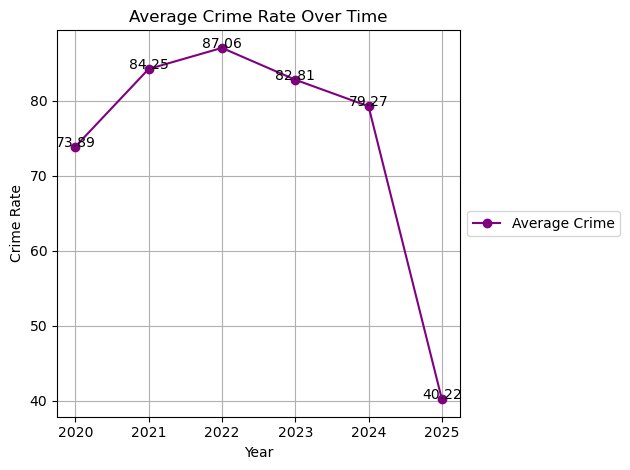

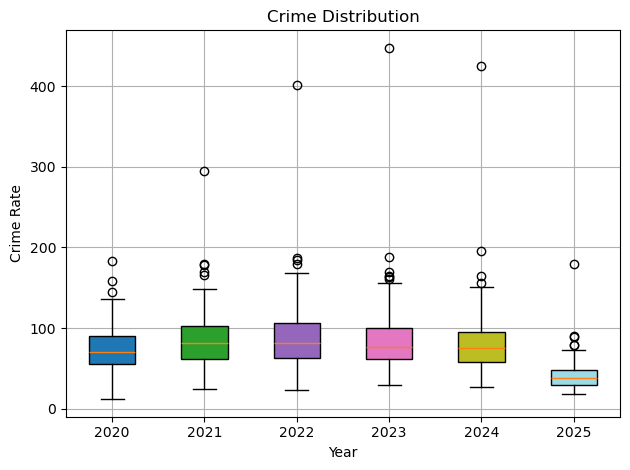

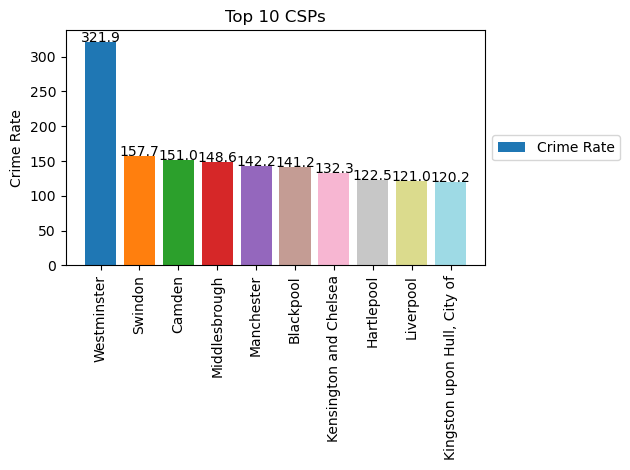

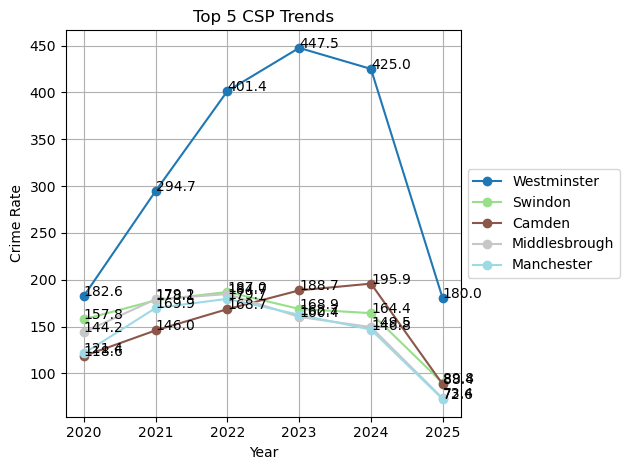

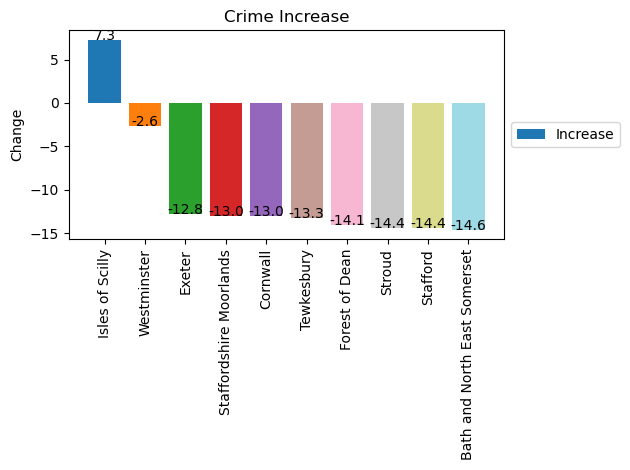

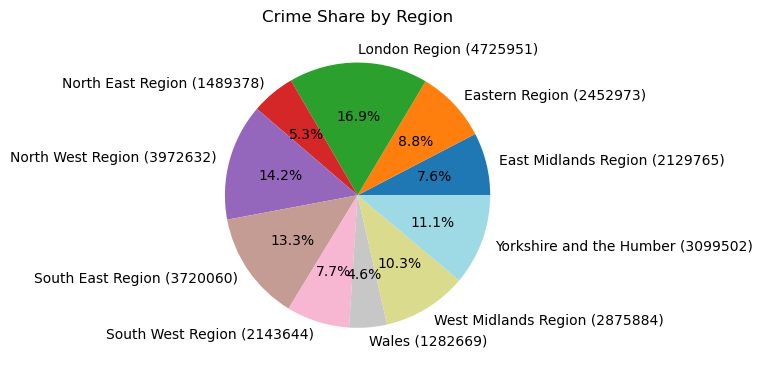

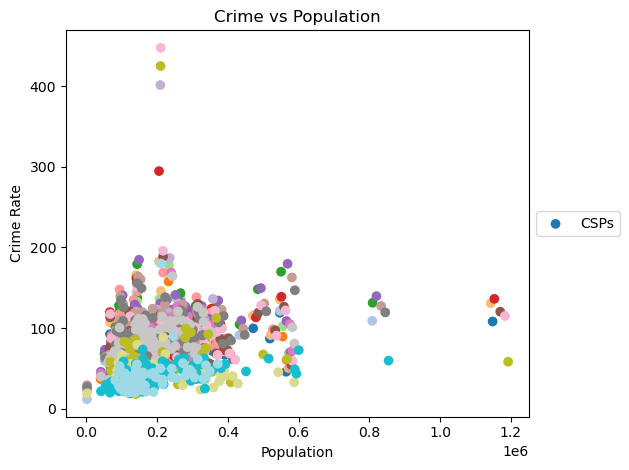

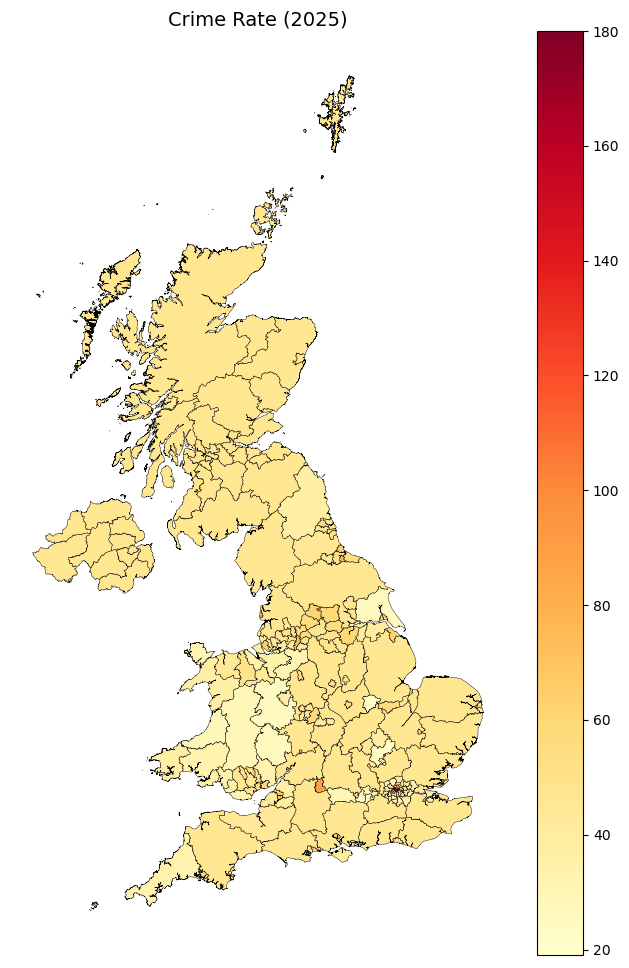

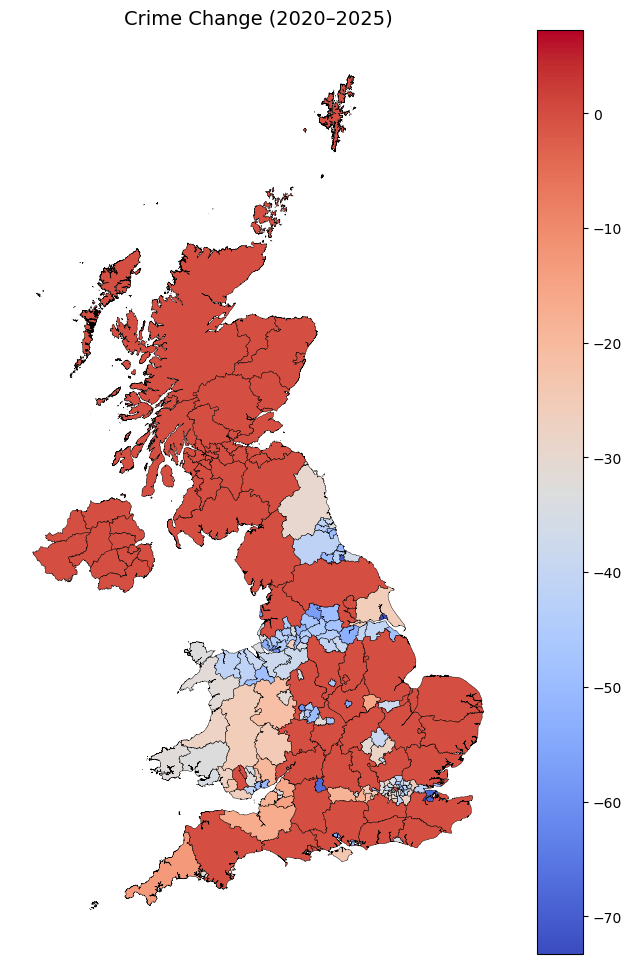

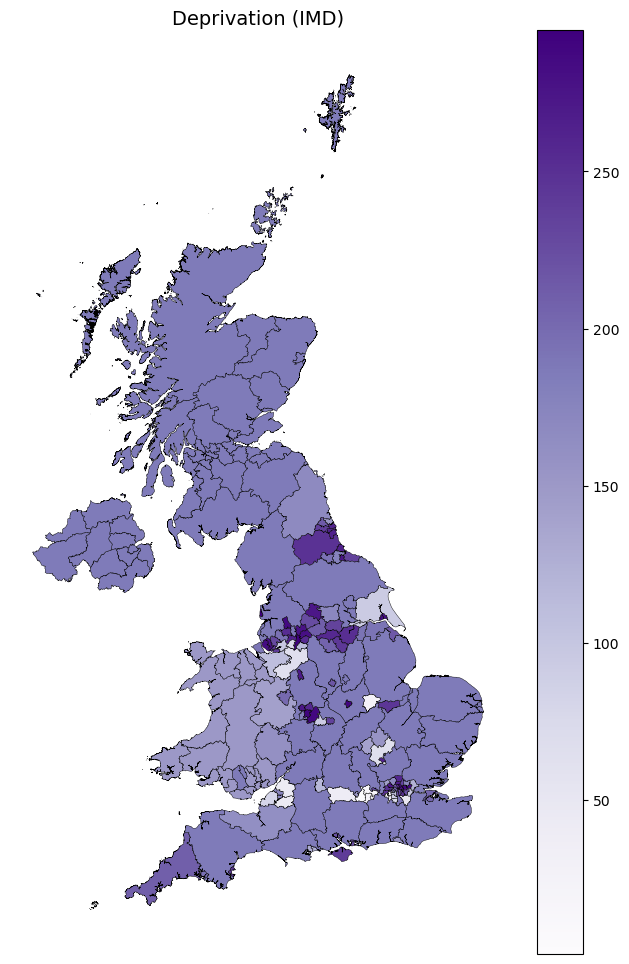

Missing after final merge (Crime): 0
Missing after final merge (IMD): 0


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

# =========================
# HELPER: UNIQUE COLORS
# =========================
def unique_colors(n):
    return plt.cm.tab20(np.linspace(0, 1, n))

# =========================
# SORT DATA
# =========================
master = master.sort_values(["Year", "CSP Name"])

# =========================
# 1. AVERAGE TREND
# =========================
avg_trend = master.groupby("Year")["Crime_Rate"].mean().reset_index()

plt.figure()
plt.plot(avg_trend["Year"], avg_trend["Crime_Rate"], marker='o', color='purple')
for x, y in zip(avg_trend["Year"], avg_trend["Crime_Rate"]):
    plt.text(x, y, f"{y:.2f}", ha='center')

plt.title("Average Crime Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Crime Rate")
plt.legend(["Average Crime"], loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 2. BOXPLOT
# =========================
years = sorted(master["Year"].unique())
data = [master.loc[master["Year"] == y, "Crime_Rate"].dropna() for y in years]

plt.figure()
box = plt.boxplot(data, patch_artist=True)

# Assign colors safely
colors = unique_colors(len(box["boxes"]))
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.xticks(range(1, len(years)+1), years)
plt.title("Crime Distribution")
plt.xlabel("Year")
plt.ylabel("Crime Rate")
plt.grid(True)
plt.tight_layout()
plt.show()
# =========================
# 3. TOP 10 BAR
# =========================
top_csp = master.groupby("CSP Name")["Crime_Rate"].mean().sort_values(ascending=False).head(10)
colors = unique_colors(len(top_csp))

plt.figure()
bars = plt.bar(top_csp.index, top_csp.values, color=colors)
for bar, val in zip(bars, top_csp.values):
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{val:.1f}", ha='center')

plt.xticks(rotation=90)
plt.title("Top 10 CSPs")
plt.ylabel("Crime Rate")
plt.legend(["Crime Rate"], loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# =========================
# 4. TOP 5 LINE
# =========================
top5 = top_csp.head(5).index
colors = unique_colors(len(top5))

plt.figure()
for i, csp in enumerate(top5):
    temp = master[master["CSP Name"] == csp]
    plt.plot(temp["Year"], temp["Crime_Rate"], marker='o', color=colors[i], label=csp)
    for x, y in zip(temp["Year"], temp["Crime_Rate"]):
        plt.text(x, y, f"{y:.1f}")

plt.title("Top 5 CSP Trends")
plt.xlabel("Year")
plt.ylabel("Crime Rate")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 5. CHANGE BAR
# =========================
pivot = master.pivot_table(index="CSP Name", columns="Year", values="Crime_Rate")
# Fill missing years with 0 to prevent errors
for y in range(master["Year"].min(), master["Year"].max()+1):
    if y not in pivot.columns:
        pivot[y] = 0

pivot["Change"] = pivot[2025] - pivot[2020]
top_change = pivot["Change"].sort_values(ascending=False).head(10)
colors = unique_colors(len(top_change))

plt.figure()
bars = plt.bar(top_change.index, top_change.values, color=colors)
for bar, val in zip(bars, top_change.values):
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{val:.1f}", ha='center')

plt.xticks(rotation=90)
plt.title("Crime Increase")
plt.ylabel("Change")
plt.legend(["Increase"], loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# =========================
# 6. PIE
# =========================
region_crime = master.groupby("Region")["Total_Crime"].sum()
colors = unique_colors(len(region_crime))
labels = [f"{r} ({v:.0f})" for r, v in zip(region_crime.index, region_crime.values)]

plt.figure()
plt.pie(region_crime.values, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title("Crime Share by Region")
plt.tight_layout()
plt.show()

# =========================
# 7. SCATTER
# =========================
colors = unique_colors(len(master))
plt.figure()
plt.scatter(master["Population"], master["Crime_Rate"], c=colors)
plt.title("Crime vs Population")
plt.xlabel("Population")
plt.ylabel("Crime Rate")
plt.legend(["CSPs"], loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# =========================
# LOAD GEOJSON
# =========================
gdf = gpd.read_file("UK_Maps.geojson")

# =========================
# CLEAN FUNCTION
# =========================
def clean(x):
    return str(x).lower().strip().replace(",", "").replace("'", "").replace(".", "").replace("&", "and")

# Use the correct column from your GeoJSON: 'ctyua18nm'
gdf["CSP_clean"] = gdf["ctyua18nm"].apply(clean)
master["CSP_clean"] = master["CSP Name"].apply(clean)

# =========================
# FIX PROJECTION
# =========================
gdf = gdf.to_crs(epsg=27700)

# =========================
# AGGREGATE MASTER TO MATCH MAP LEVEL
# =========================
data_2025 = master[master["Year"] == 2025].groupby("CSP_clean").agg({
    "Crime_Rate": "mean",
    "IMD": "mean"
}).reset_index()

# =========================
# MAP 1: CRIME RATE
# =========================
map1 = gdf.merge(data_2025, on="CSP_clean", how="left")
map1["Crime_Rate"] = map1["Crime_Rate"].fillna(map1["Crime_Rate"].mean())

fig, ax = plt.subplots(figsize=(8, 12))
map1.plot(column="Crime_Rate", cmap="YlOrRd", linewidth=0.3, edgecolor="black", legend=True, ax=ax)
ax.set_title("Crime Rate (2025)", fontsize=14)
ax.axis("off")
plt.show()

# =========================
# MAP 2: CRIME CHANGE
# =========================
pivot_geo = master.pivot_table(index="CSP_clean", columns="Year", values="Crime_Rate", aggfunc="mean")
for y in range(master["Year"].min(), master["Year"].max()+1):
    if y not in pivot_geo.columns:
        pivot_geo[y] = 0
pivot_geo["Change"] = pivot_geo[2025] - pivot_geo[2020]
pivot_geo = pivot_geo.reset_index()

map2 = gdf.merge(pivot_geo[["CSP_clean", "Change"]], on="CSP_clean", how="left")
map2["Change"] = map2["Change"].fillna(0)

fig, ax = plt.subplots(figsize=(8, 12))
map2.plot(column="Change", cmap="coolwarm", linewidth=0.3, edgecolor="black", legend=True, ax=ax)
ax.set_title("Crime Change (2020–2025)", fontsize=14)
ax.axis("off")
plt.show()

# =========================
# MAP 3: IMD
# =========================
map3 = gdf.merge(data_2025, on="CSP_clean", how="left")
map3["IMD"] = map3["IMD"].fillna(map3["IMD"].mean())

fig, ax = plt.subplots(figsize=(8, 12))
map3.plot(column="IMD", cmap="Purples", linewidth=0.3, edgecolor="black", legend=True, ax=ax)
ax.set_title("Deprivation (IMD)", fontsize=14)
ax.axis("off")
plt.show()

# =========================
# FINAL CHECK
# =========================
print("Missing after final merge (Crime):", map1["Crime_Rate"].isna().sum())
print("Missing after final merge (IMD):", map3["IMD"].isna().sum())

In [44]:
!pip install linearmodels

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 11.3 MB/s eta 0:00:00


### PHASE 4: REGRESSION

C:\Users\Bindu\anaconda3\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
C:\Users\Bindu\anaconda3\Lib\site-packages\linearmodels\panel\model.py:2751: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)



===== FIXED EFFECTS RESULTS =====
                          PanelOLS Estimation Summary                           
Dep. Variable:             Crime_Rate   R-squared:                        0.0012
Estimator:                   PanelOLS   R-squared (Between):              0.3376
No. Observations:                1656   R-squared (Within):              -0.0038
Date:                Fri, Apr 03 2026   R-squared (Overall):              0.3200
Time:                        10:13:41   Log-likelihood                   -6082.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.7144
Entities:                         276   P-value                           0.1906
Avg Obs:                       6.0000   Distribution:                  F(1,1374)
Min Obs:                       6.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             

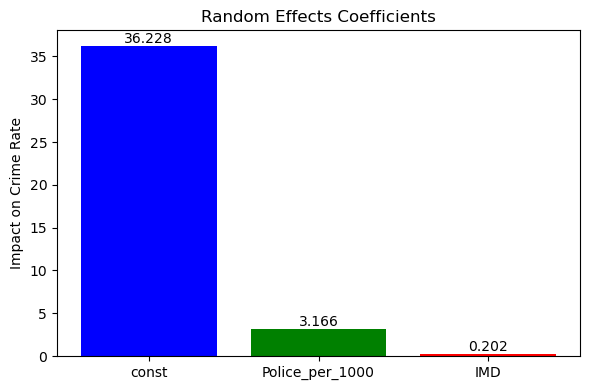

In [45]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS, RandomEffects
from statsmodels.tools.tools import add_constant
from scipy import stats

# =========================
# PREP DATA
# =========================
df = master.copy()

# Clean CSP names for consistency
df["CSP_clean"] = df["CSP Name"].str.lower().str.strip()

# Set multi-index for panel (CSP + Year)
df = df.set_index(["CSP_clean", "Year"])

# Dependent variable
y = df["Crime_Rate"]

# =========================
# FIXED EFFECTS MODEL (FE)
# Drop IMD for FE
# =========================
X_fe = df[["Police_per_1000"]]

fe_model = PanelOLS(
    y,
    X_fe,
    entity_effects=True,
    time_effects=True
)

fe_results = fe_model.fit(cov_type="clustered", cluster_entity=True)
print("\n===== FIXED EFFECTS RESULTS =====")
print(fe_results.summary)

# =========================
# RANDOM EFFECTS MODEL (RE)
# Keep IMD
# =========================
X_re = add_constant(df[["Police_per_1000", "IMD"]])
re_model = RandomEffects(y, X_re)
re_results = re_model.fit()
print("\n===== RANDOM EFFECTS RESULTS =====")
print(re_results.summary)

# =========================
# HAUSMAN TEST
# =========================
b_fe = fe_results.params
b_re = re_results.params.loc[b_fe.index]

diff = b_fe - b_re

cov_fe = fe_results.cov
cov_re = re_results.cov.loc[b_fe.index, b_fe.index]

# Hausman statistic
stat = np.dot(diff.T, np.linalg.inv(cov_fe - cov_re)).dot(diff)
df_h = len(diff)
p_value = 1 - stats.chi2.cdf(stat, df_h)

print("\n===== HAUSMAN TEST =====")
print("Chi2 Statistic:", stat)
print("Degrees of Freedom:", df_h)
print("p-value:", p_value)

# =========================
# RANDOM EFFECTS COEFFICIENT PLOT
# =========================
coef = re_results.params

plt.figure(figsize=(6,4))
plt.bar(coef.index, coef.values, color=['blue','green','red'])

for i, v in enumerate(coef.values):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.title("Random Effects Coefficients")
plt.ylabel("Impact on Crime Rate")
plt.tight_layout()
plt.show()

### PHASE 5: SPATIAL ECONOMETRICS

In [46]:
!pip install libpysal esda splot

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 20.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   ---------------------------------------- 882.2/882.2 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: platformdirs
    Found existing installation: platformdirs 3.10.0
    Uninstalling platformdirs-3.10.0:
      Successfully uninstalled platformdirs-3.10.0
  Attempting uninstall: beautifulsoup4
    Found existing installation: beautifulsoup4 4.12.3
    Uninstalling beautifulsoup4-4.12.3:
      Successfully uninstalled beautifulsoup4-4.12.3


GeoJSON columns: Index(['OBJECTID', 'ctyua18cd', 'ctyua18nm', 'ctyua18nmw', 'bng_e', 'bng_n',
       'long', 'lat', 'GlobalID', 'geometry'],
      dtype='object')
Total areas: 216
Areas with data: 141


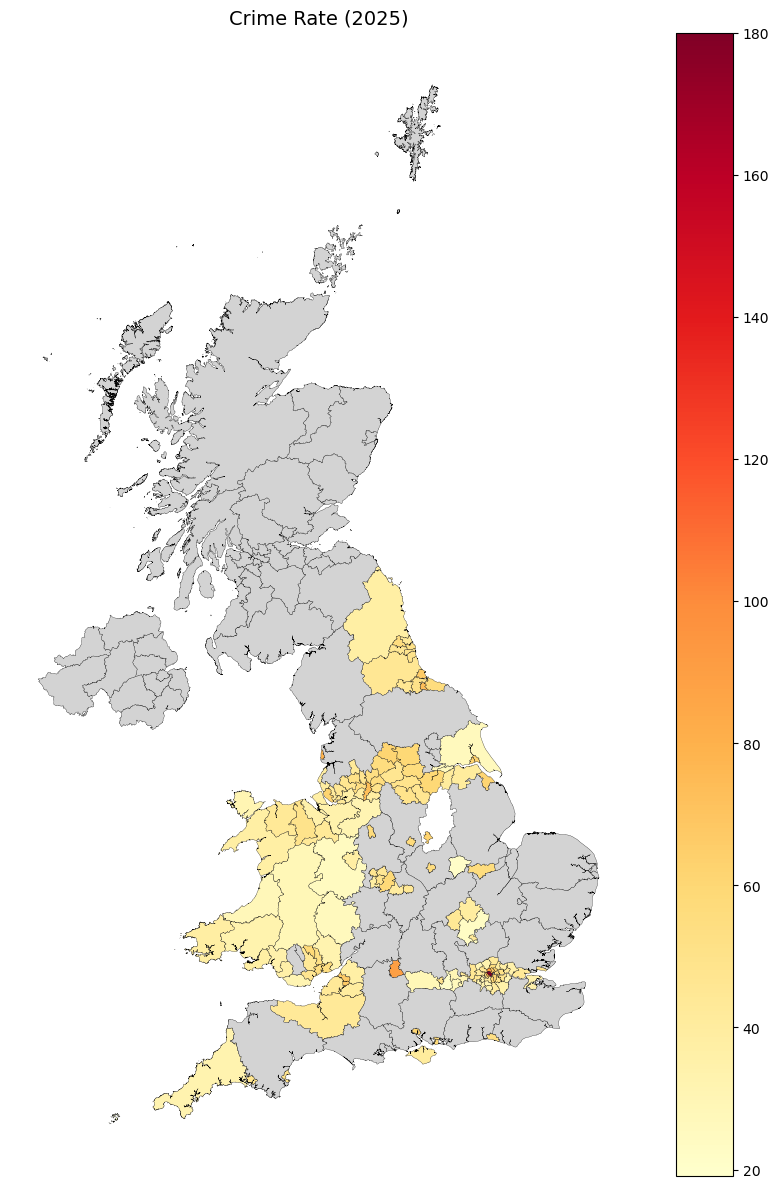

Components in W: [0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0
 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

===== MORAN'S I =====
I: 0.13591871432995548
p-value: 0.051


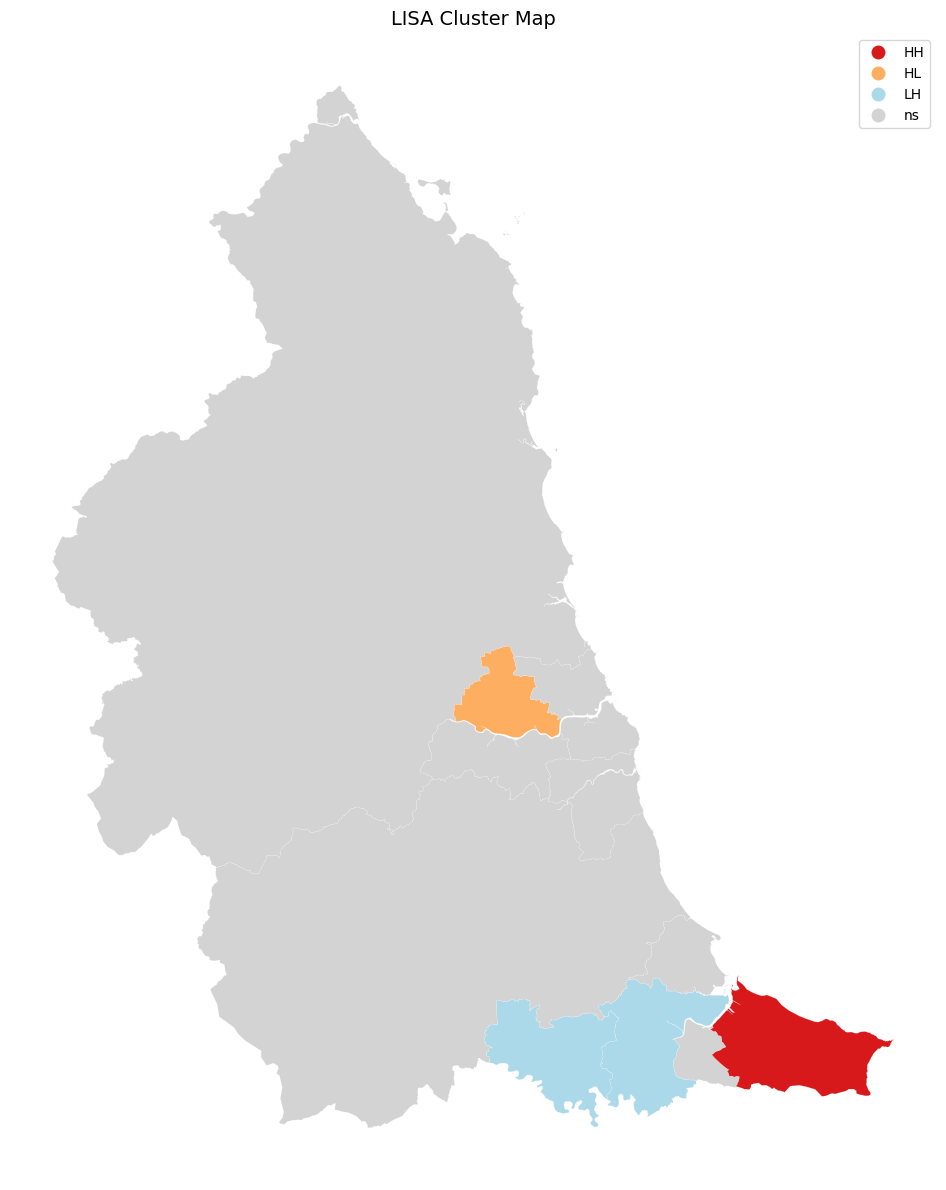

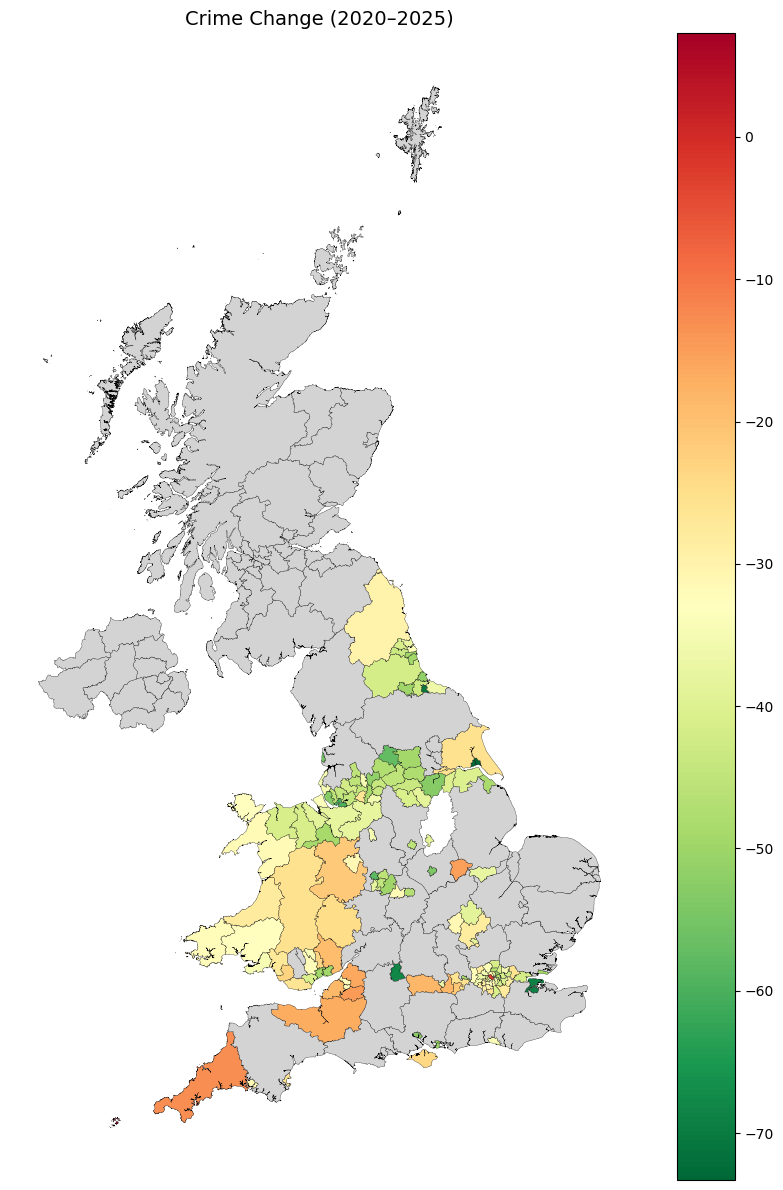

ML_Lag

===== SPATIAL LAG MODEL =====
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:          12
Mean dependent var  :      0.2776                Number of Variables   :           4
S.D. dependent var  :      0.5897                Degrees of Freedom    :           8
Pseudo R-squared    :      0.5375
Spatial Pseudo R-squared:  0.4501
Log likelihood      :     -5.7973
Sigma-square ML     :      0.1477                Akaike info criterion :      19.595
S.E of regression   :      0.3844                Schwarz criterion     :      21.534

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------

C:\Users\Bindu\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


In [49]:
# =========================
# PHASE 5: SPATIAL ANALYSIS (FULL UK)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# For spatial stats
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local
from splot.esda import lisa_cluster
from spreg import ML_Lag, ML_Error
from sklearn.preprocessing import StandardScaler

# =========================
# LOAD GEOJSON (FULL UK)
# =========================
gdf = gpd.read_file("UK_Maps.geojson")

# Check columns
print("GeoJSON columns:", gdf.columns)

# =========================
# CLEAN FUNCTION
# =========================
def clean(x):
    return str(x).lower().strip().replace(",", "").replace("'", "").replace(".", "").replace("&", "and")

# Use correct column from your GeoJSON
gdf["CSP_clean"] = gdf["ctyua18nm"].apply(clean)
master["CSP_clean"] = master["CSP Name"].apply(clean)

# =========================
# FIX GEOMETRY
# =========================
gdf = gdf.to_crs(epsg=27700)
gdf = gdf[gdf.geometry.notnull()]
gdf = gdf[gdf.is_valid]

# =========================
# PREPARE DATA (2025)
# =========================
data_2025 = (
    master[master["Year"] == 2025]
    .groupby("CSP_clean", as_index=False)
    .agg({
        "Crime_Rate": "mean",
        "IMD": "mean",
        "Police_per_1000": "mean"
    })
)

# =========================
# LEFT JOIN: MAP DATA
# =========================
geo = gdf.merge(data_2025, on="CSP_clean", how="left")

# Study area flag
geo["Study_Area"] = geo["Crime_Rate"].notna()

print("Total areas:", len(geo))
print("Areas with data:", geo["Study_Area"].sum())

# =========================
# MAP 1: FULL UK CRIME RATE 2025
# =========================
fig, ax = plt.subplots(figsize=(10, 12))

geo.plot(
    column="Crime_Rate",
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data (Outside Study Area)"
    }
)

ax.set_title("Crime Rate (2025)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

# =========================
# FILTER VALID DATA FOR SPATIAL ANALYSIS
# =========================
geo_valid = geo[geo["Study_Area"]].copy()

# =========================
# STANDARDISE VARIABLES
# =========================
scaler = StandardScaler()
geo_valid["Crime_std"] = scaler.fit_transform(geo_valid[["Crime_Rate"]])
geo_valid["IMD_std"] = scaler.fit_transform(geo_valid[["IMD"]])
geo_valid["Police_std"] = scaler.fit_transform(geo_valid[["Police_per_1000"]])

# =========================
# SPATIAL WEIGHTS (KNN)
# =========================
# Identify components
print("Components in W:", w.component_labels)  # array with component index for each polygon

# Keep only the largest connected component
largest_comp = (w.component_labels == 0)
geo_valid = geo_valid[largest_comp]
w = KNN.from_dataframe(geo_valid, k=5)
w.transform = "r"

# =========================
# MORAN'S I (SPATIAL AUTOCORRELATION)
# =========================
y = geo_valid["Crime_std"].values
moran = Moran(y, w)

print("\n===== MORAN'S I =====")
print("I:", moran.I)
print("p-value:", moran.p_sim)

# =========================
# MAP 2: LISA CLUSTER MAP
# =========================
lisa = Moran_Local(y, w)

fig, ax = plt.subplots(figsize=(10, 12))
lisa_cluster(lisa, geo_valid, p=0.05, ax=ax)
ax.set_title("LISA Cluster Map", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

# =========================
# MAP 3: CRIME CHANGE (2020-2025)
# =========================
pivot = master.pivot_table(index="CSP_clean", columns="Year", values="Crime_Rate", aggfunc="mean")
pivot["Change"] = pivot[2025] - pivot[2020]
pivot = pivot.reset_index()

geo_change = gdf.merge(pivot[["CSP_clean", "Change"]], on="CSP_clean", how="left")

fig, ax = plt.subplots(figsize=(10, 12))
geo_change.plot(
    column="Change",
    cmap="RdYlGn_r",
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)
ax.set_title("Crime Change (2020–2025)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

# =========================
# SPATIAL REGRESSION
# =========================
y_reg = geo_valid["Crime_std"].values.reshape(-1, 1)
X_reg = geo_valid[["IMD_std", "Police_std"]].values

slag = ML_Lag(y_reg, X_reg, w=w)
print("\n===== SPATIAL LAG MODEL =====")
print(slag.summary)

serror = ML_Error(y_reg, X_reg, w=w)
print("\n===== SPATIAL ERROR MODEL =====")
print(serror.summary)

print("\nSPATIAL ANALYSIS COMPLETE ")